## YOLO로 이미지 분류 모델 작성하기


-  욜로(YOLO)는 객체 탐지(Object Detection)를 위해 설계된 모델이지만, 이미지 분류(Image Classification) 작업에도 매우 유용하게 사용할 수 있다.
- YOLO기반 분류 모델 : ex) YOLO-cls

In [1]:
!pip install ultralytics opencv-python

In [2]:
# flower dataset 사용
import random
import shutil
from pathlib import Path
import tensorflow as tf
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

datatset_path = tf.keras.utils.get_file(
    fname="flower_photos",
    origin="http://download.tensorflow.org/example_images/flower_photos.tgz", # 경로
    untar=True,
)

SOURCE_DIR = Path(datatset_path) / "flower_photos"
print(f'SOURCE_DIR : {SOURCE_DIR}')
# 데이터 다운로드 위치 : /root/.keras/datasets/flower_photos/flower_photos

classes = [p.name for p in SOURCE_DIR.iterdir() if p.is_dir()]
print("classes :",classes)
# class목록 : ['sunflowers', 'roses', 'tulips', 'daisy', 'dandelion']

SOURCE_DIR : /root/.keras/datasets/flower_photos/flower_photos
classes : ['dandelion', 'tulips', 'roses', 'daisy', 'sunflowers']


In [3]:
# YOLO 학습용 데이터셋 폴더 생성
DATASET_DIR = Path("flower_dataset")

# 중복 방지
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR) # 기존 데이터가 있다면 디렉토리를 지워라

# train / val / test 폴더 생성 후 분할된 데이터 저장
TRAIN_DIR = DATASET_DIR/'train'
VAL_DIR = DATASET_DIR/'val'
TEST_DIR = DATASET_DIR/'test'

for class_dir in SOURCE_DIR.iterdir():
  if not class_dir.is_dir(): # 폴더가 아니면 skip
    continue

  class_name = class_dir.name   # 클래스 이름 저장(ex, dasiy...)

  images = list(class_dir.glob("*.*")) # 모든 이미지 파일을 가져옴
  if len(images) == 0: # 쭉 진행하다가 이미지가 없으면 skip
    continue

  random.shuffle(images) # 학습 편향 방지를 목적으로 이미지를 데이터 섞음

  total = len(images)
  print("total :",total)

  train_end = int(total * 0.7)  # 70%
  val_end = int(total * 0.9)    # 90%

  # 데이터 분할하기 (7 : 2 : 1)
  splits = {
      "train": images[:train_end],      # 0% ~ 70%
      "val": images[train_end:val_end], # 70% ~ 90%
      "test": images[val_end:],         # 90% ~
  }
  print(len(splits['train']), len(splits['val']), len(splits['test']))

  # 분할된 데이터 이미지 각 폴더에 복사하기.
  for split_name, split_images in splits.items():
    target_dir = DATASET_DIR / split_name / class_name  # 저장경로 생성하기
    target_dir.mkdir(parents=True, exist_ok=True)       # 디렉토리 없는 경우 생성

    # 파일 복사하기
    for img in split_images:
      # copy2 : 파일 메타정보까지 복사
      shutil.copy2(img, target_dir/img.name)

# dataset 확인하기 (정상생성 여부를 확인)
for split in ["train", "val", "test"]:
    print(f"{"="*10} Split: [{split}] {"="*10}")
    for class_dir in (DATASET_DIR/split).iterdir(): # 클래스별 폴더 탐색
      count = len(list(class_dir.glob("*.*")))      # 이미지 건수
      print(f"{class_dir.name}의 Count(건수)는 {count}")

total : 898
628 180 90
total : 799
559 160 80
total : 641
448 128 65
total : 633
443 126 64
total : 699
489 140 70
========== Split: [train] ==========
dandelion의 Count(건수)는 628
tulips의 Count(건수)는 559
roses의 Count(건수)는 448
daisy의 Count(건수)는 443
sunflowers의 Count(건수)는 489
========== Split: [val] ==========
dandelion의 Count(건수)는 180
tulips의 Count(건수)는 160
roses의 Count(건수)는 128
daisy의 Count(건수)는 126
sunflowers의 Count(건수)는 140
========== Split: [test] ==========
dandelion의 Count(건수)는 90
tulips의 Count(건수)는 80
roses의 Count(건수)는 65
daisy의 Count(건수)는 64
sunflowers의 Count(건수)는 70


### 사전 학습된 YOLO11 분류 모델 다시 학습시키기
- 원래는 80개의 class로 분류가 가능하도록 사전 학습되어있는 모델이기 떄문에 내 데이터에 맞는 학습을 다시 시켜줘야한다.

In [4]:
#사전 학습된 YOLO11 분류 모델 다시 학습시키기 (train + val 사용)
model = YOLO('yolo11n-cls.pt') # 사전 학습된 YOLO11 classification model 로딩

model.train(
    # 무조건 절대 경로 사용! (resolve() : 상대경로를 절대경로로 변경해줌)
    data = str(DATASET_DIR.resolve()),
    epochs = 5,
    imgsz = 224,
    batch = 16,
    device = '0' # T4 GPU를 사용하려면 '0'으로 설정
)
print('학습 완료') #  0.958

Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/flower_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

test acc : 97.29%
              precision    recall  f1-score   support

       daisy       0.98      0.98      0.98        64
   dandelion       0.98      1.00      0.99        90
       roses       0.94      0.97      0.95        65
  sunflowers       1.00      0.94      0.97        70
      tulips       0.96      0.96      0.96        80

    accuracy                           0.97       369
   macro avg       0.97      0.97      0.97       369
weighted avg       0.97      0.97      0.97       369



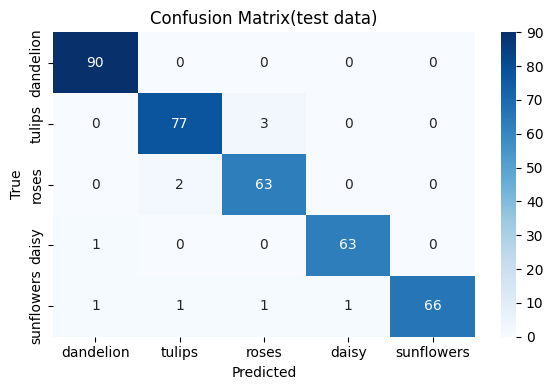

In [5]:
# 학습된 모델의 성능 측정하기 - 가장 좋은 모델 로딩
best_model = YOLO('/content/runs/classify/train/weights/best.pt')

y_true = [] # 실제 정답
y_pred = [] # 모델이 예측한 값

test_dir = DATASET_DIR/'test'
# 클래스별 반복(폴더 순회)
for class_dir in test_dir.iterdir():
  # label = 폴더명 얻기
  true_label = class_dir.name

  # 이미지 반복하기
  for img_path in class_dir.glob("*.*"):
    # 예측 수행하기
    results = best_model.predict(
        source = str(img_path),
        imgsz = 224,
        verbose = False
    )

    r = results[0] # 결과 한개를 추출해봄
    pred_idx = r.probs.top1 # 확률값 가장 높은 클래스의 인덱스를 추출
    pred_label = r.names[pred_idx] # 클래스 이름 반환

    y_true.append(true_label) # 실제값
    y_pred.append(pred_label) # 예측값

# 성능 확인하기
acc = accuracy_score(y_true, y_pred)
print(f"test acc : {acc*100:.2f}%")

print(classification_report(y_true, y_pred))

# heatmap으로 혼돈행렬 시각화
cm = confusion_matrix(y_true, y_pred, labels=classes)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes
)
plt.title('Confusion Matrix(test data)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('yolo11cm.png')
plt.show()

In [6]:
# 새로운 이미지 분류하기
sample_path = Path('myflower.jpg') # 장미 이미지

if sample_path.exists:
  results = best_model.predict(
      source = str(sample_path),
      imgsz = 224,
      verbose = False
  )
  r = results[0]
  pred_idx = r.probs.top1
  pred_label = r.names[pred_idx]
  print(f'분류 결과 : {pred_label}')
  confidence = float(r.probs.top1conf) # 확신도

  print(sample_path)
  print(f'분류 결과 : {pred_label}')
  print(f'확신도 : {confidence*100:.2f}%')
else:
  print('파일 없음')

분류 결과 : roses
myflower.jpg
분류 결과 : roses
확신도 : 99.96%
